In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
vars_atto = ["Tair_36m", "q_36m", "LW_atm_calc", 'SW_in_GF (W/m2)',  'AP_36m_kPa','WSp_50m', "Rainfall"]
vars_zf2 = ["TA", "Q", "LW_IN", 'SW_IN_PI_F',  'PA', 'WS', "P"]

In [3]:
    
def gen_plot(df_input, varname):
    
    dfs = df_input
    dfs['Year'] = dfs.index.year
    dfs['Month'] = dfs.index.month
    dfs['Day_of_year'] = dfs.index.dayofyear
    
    
    fig, ax = plt.subplots(3, 2, figsize=(12,8))
    
    cols = ['red', 'blue']
    variants = ['zf2', 'atto']
    

    for i in range(0,2):
        
        if i == 0:
            df = dfs.loc["2000-01-01":"2013-12-31"]        
        if i == 1:
            df = dfs.loc["2014-01-01":"2023-12-31"]


        varnamef = varname

        ax[0,0].plot(df[varnamef], alpha = 0.6, c= cols[i])
        ax[0,0].set_ylabel(varnamef)
        
        df_zf2_grp = df.groupby(['Year', 'Month'])[varnamef].mean().reset_index()
        df_zf2_grp['Period'] = pd.to_datetime(
            df_zf2_grp['Year'].astype(str) + '-' + df_zf2_grp['Month'].astype(str) + '-01'
        )
        df_zf2_grp.set_index(df_zf2_grp['Period'], inplace=True)


        ax[1,0].plot(df_zf2_grp[varnamef], alpha = 0.6, c= cols[i])
        ax[1,0].set_ylabel(varnamef)

        df_zf2_grp = df.groupby(['Year'])[varnamef].mean().reset_index()
        df_zf2_grp['Period'] = pd.to_datetime(
            df_zf2_grp['Year'].astype(str) + '-01-01'
        )
        df_zf2_grp.set_index(df_zf2_grp['Period'], inplace=True)
        ax[2,0].plot(df_zf2_grp[varnamef], alpha = 0.6, c= cols[i], label= variants[i])
        ax[2,0].set_ylabel(varnamef)
        ax[2,0].legend()

        df_zf2_grp = df.groupby(['Day_of_year'])[varnamef].mean().reset_index()

        ax[0,1].plot(df_zf2_grp[varnamef], alpha = 0.6, c= cols[i])
        ax[1,1].set_xlabel("Average Year")
        
        df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
        df_zf2_grp = pd.DataFrame(df_zf2_grp.groupby(df_zf2_grp.index.time).mean())

        ax[1,1].plot(np.arange(0,24, 0.5),df_zf2_grp[varnamef].values, alpha = 0.6, c= cols[i])
        ax[1,1].set_ylabel(varnamef)
        ax[1,1].set_xlabel("Average Day")

    plt.subplots_adjust(hspace= 0.3)
    plt.show()
    #plt.savefig(f"{vnameZf}.png", dpi =300);

In [3]:
df_zf2 = pd.read_csv("../data/BR-Ma2/ZF2_gapfilled.csv")
df_zf2.set_index(pd.to_datetime(df_zf2['datetime']), inplace= True)
df_zf2 = df_zf2.loc["2000-01-01":"2013-12-31"]
df_zf2 = df_zf2[~((df_zf2.index.month == 2) & (df_zf2.index.day == 29))]
df_zf2["SW_IN_PI_F_filled"] = df_zf2["SW_IN_PI_F_filled"].clip(lower =0.0)
df_atto = pd.read_csv("../data/ATTO_gapfilled.csv")
df_atto.set_index(pd.to_datetime(df_atto['datetime']), inplace= True)
df_atto = df_atto.loc["2014-01-01":"2023-12-31"]
df_atto = df_atto[~((df_atto.index.month == 2) & (df_atto.index.day == 29))]

# ATTO is missing the last 5 hours on the last day of december. we are just copyign the last value
# Target end time
end_time = pd.Timestamp("2023-12-31 23:30:00")

# Generate new datetime index in 30-minute steps
new_index = pd.date_range(df_atto.index[-1] + pd.Timedelta(minutes=30),
                          end_time,
                          freq="30min")

# Repeat the last row’s values for the new times
last_row = df_atto.iloc[[-1]]  # keep as DataFrame
extension = pd.concat([last_row] * len(new_index), ignore_index=True)
extension.index = new_index

# Append to original df
df_atto = pd.concat([df_atto, extension], axis=0)

In [4]:
df_atto

,datetime,Tair_36m,Tair_36m_flag,Tair_36m_filled,q_36m,q_36m_flag,q_36m_filled,LW_atm_calc,LW_atm_calc_flag,LW_atm_calc_filled,SW_in_GF (W/m2),SW_in_GF (W/m2)_flag,SW_in_GF (W/m2)_filled,AP_36m_kPa,AP_36m_kPa_flag,AP_36m_kPa_filled,WSp_50m,WSp_50m_flag,WSp_50m_filled,Rainfall
2014-01-01 00:00:00,2014-01-01 00:00:00,25.202333,0,25.202333,0.017911,0,0.017911,409.628952,0,409.628952,0.0,0,0.0,99.402765,0,99.402765,2.472000,0,2.472000,0.0
2014-01-01 00:30:00,2014-01-01 00:30:00,24.951333,0,24.951333,0.017949,0,0.017949,412.822124,0,412.822124,0.0,0,0.0,99.363587,0,99.363587,2.436000,0,2.436000,0.0
2014-01-01 01:00:00,2014-01-01 01:00:00,24.761333,0,24.761333,0.018005,0,0.018005,412.451342,0,412.451342,0.0,0,0.0,99.336000,0,99.336000,2.525667,0,2.525667,0.0
2014-01-01 01:30:00,2014-01-01 01:30:00,24.455667,0,24.455667,0.018128,0,0.018128,412.097304,0,412.097304,0.0,0,0.0,99.297874,0,99.297874,2.361667,0,2.361667,0.0
2014-01-01 02:00:00,2014-01-01 02:00:00,24.241667,0,24.241667,0.018176,0,0.018176,407.867095,0,407.867095,0.0,0,0.0,99.257692,0,99.257692,2.387333,0,2.387333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00,2023-12-31 19:00:00,23.503000,0,23.503000,0.018628,0,0.018628,410.952674,0,410.952674,0.0,0,0.0,99.354141,0,99.354141,NaN,1,NaN,0.0
2023-12-31 22:00:00,2023-12-31 19:00:00,23.503000,0,23.503000,0.018628,0,0.018628,410.952674,0,410.952674,0.0,0,0.0,99.354141,0,99.354141,NaN,1,NaN,0.0
2023-12-31 22:30:00,2023-12-31 19:00:00,23.503000,0,23.503000,0.018628,0,0.018628,410.952674,0,410.952674,0.0,0,0.0,99.354141,0,99.354141,NaN,1,NaN,0.0
2023-12-31 23:00:00,2023-12-31 19:00:00,23.503000,0,23.503000,0.018628,0,0.018628,410.952674,0,410.952674,0.0,0,0.0,99.354141,0,99.354141,NaN,1,NaN,0.0


In [5]:
id = 0

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

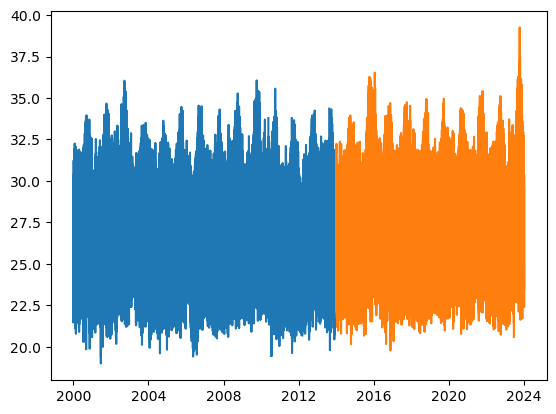

In [6]:
plt.plot(df_zf2[var_zf2])
plt.plot(df_atto[var_atto])

In [7]:
for i in range(2014, 2024):
    df_atto_sl = df_atto.loc[f"{i}-01-01":f"{i}-12-31"]
    if df_atto_sl.shape[0] % 17520 == 0:
        print(f"{i} passed! ✅")
    else:
        print(f"{i} fails ❌")

2014 passed! ✅
2015 passed! ✅
2016 passed! ✅
2017 passed! ✅
2018 passed! ✅
2019 passed! ✅
2020 passed! ✅
2021 passed! ✅
2022 passed! ✅
2023 passed! ✅


In [8]:
for i in range(2000, 2014):
    df_zf_sl = df_zf2.loc[f"{i}-01-01":f"{i}-12-31"]
    if (df_zf_sl.shape[0] % 17520 == 0) & (df_zf_sl.shape[0]  > 0) :
        print(f"{i} passed! ✅")
    else:
        print(f"{i} fails ❌")

2000 passed! ✅
2001 passed! ✅
2002 passed! ✅
2003 passed! ✅
2004 passed! ✅
2005 passed! ✅
2006 passed! ✅
2007 passed! ✅
2008 passed! ✅
2009 passed! ✅
2010 passed! ✅
2011 passed! ✅
2012 passed! ✅
2013 passed! ✅


24.0


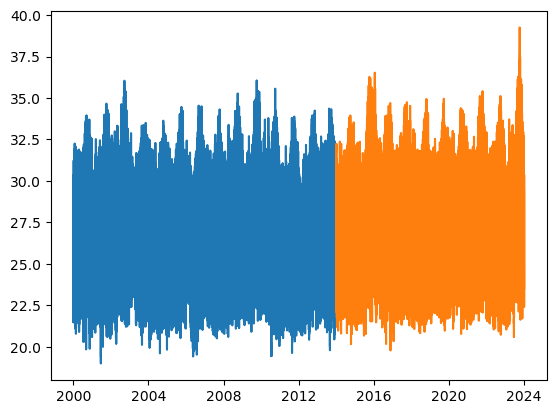

In [9]:
id = 0

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

df_final_T = pd.DataFrame(df_zf2[f"{var_zf2}_filled"])
df2 = df_atto.rename(columns={f"{var_atto}_filled": f"{var_zf2}_filled"})
df_final_T = pd.concat([df_final_T, df2[f"{var_zf2}_filled"]], axis=0)
print(df_final_T.shape[0]/17520)

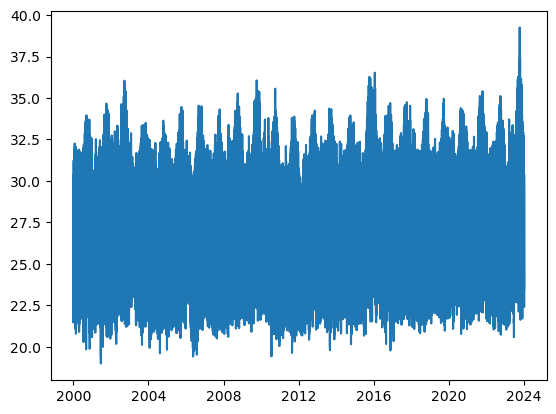

In [10]:
plt.plot(df_final_T[f"{var_zf2}_filled"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


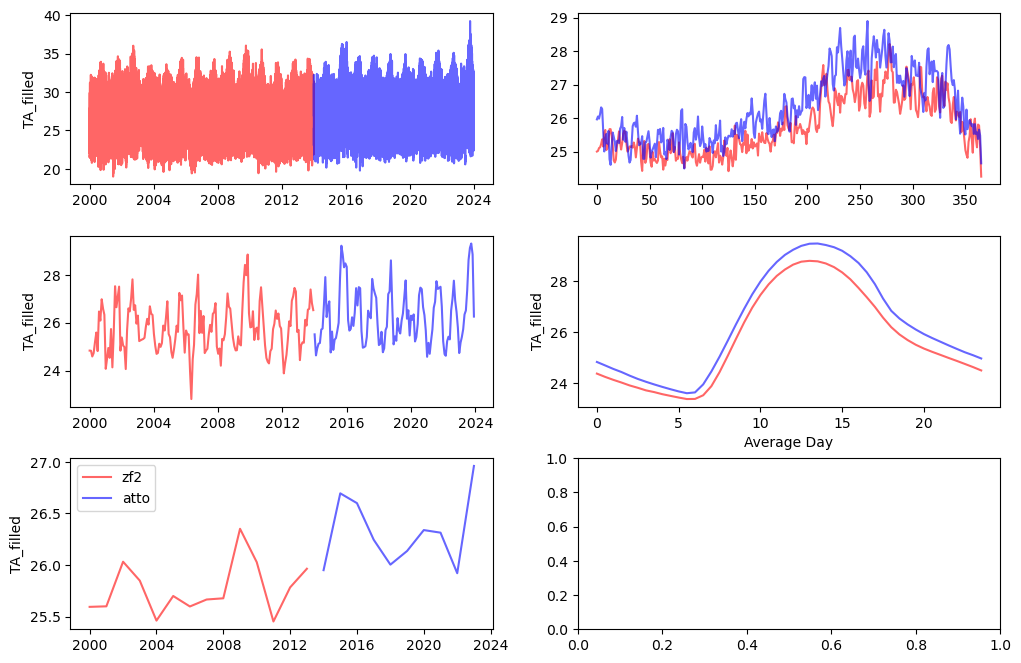

In [11]:
gen_plot(df_final_T, f"{var_zf2}_filled")

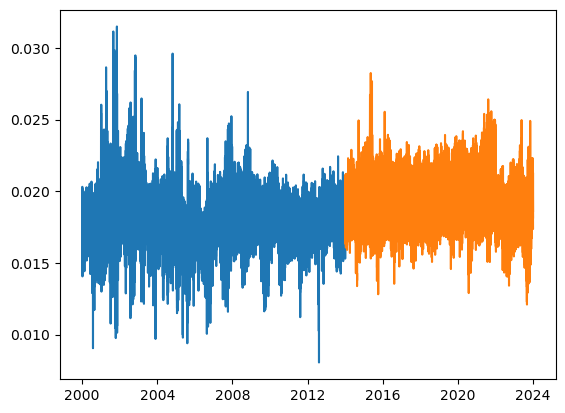

In [12]:
id =1

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

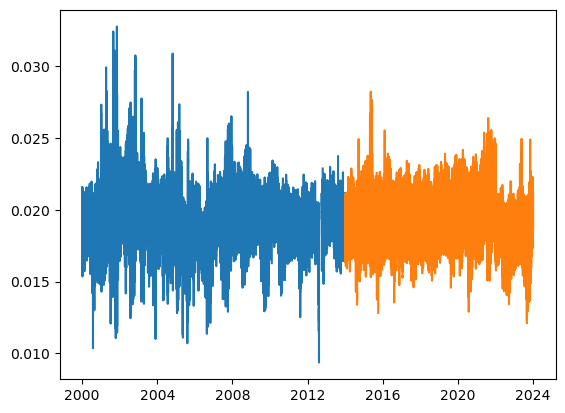

In [13]:
bias_adust =( df_atto[var_atto].mean()-df_zf2[var_zf2].mean() )
plt.plot(df_zf2[var_zf2] + bias_adust)
plt.plot(df_atto[var_atto])

24.0


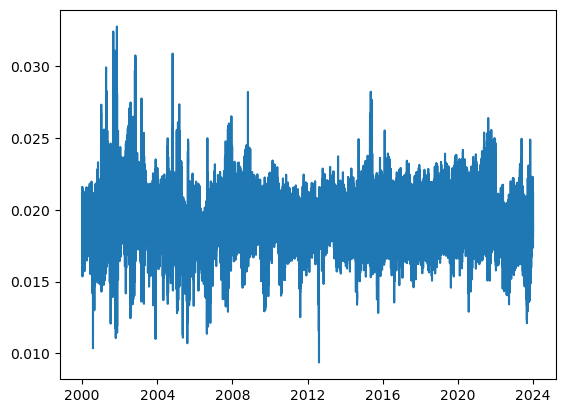

In [14]:
df_final_Q= pd.DataFrame(df_zf2[f"{var_zf2}_filled"]+ bias_adust)
df2 = df_atto.rename(columns={f"{var_atto}_filled": f"{var_zf2}_filled"})
df_final_Q = pd.concat([df_final_Q, df2[f"{var_zf2}_filled"]], axis=0)
print(df_final_Q.shape[0]/17520)
plt.plot(df_final_Q[f"{var_zf2}_filled"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


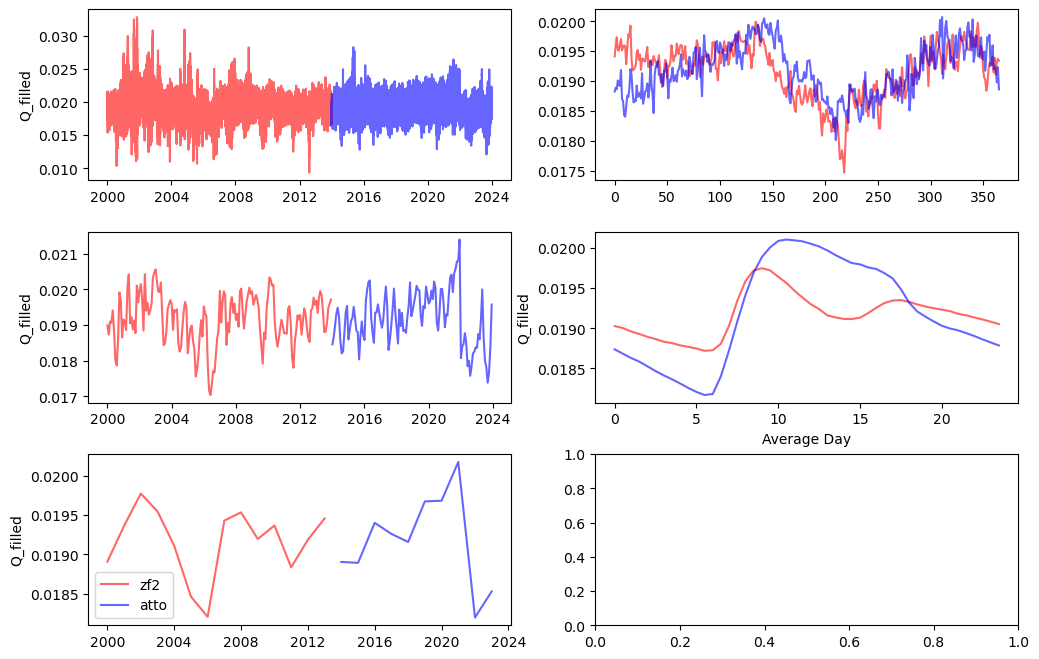

In [15]:
gen_plot(df_final_Q, f"{var_zf2}_filled")

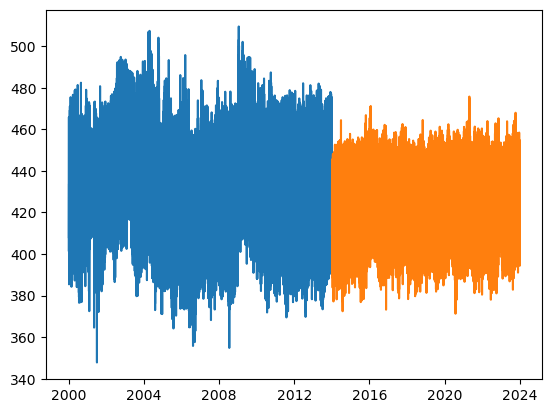

In [16]:
id = 2

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

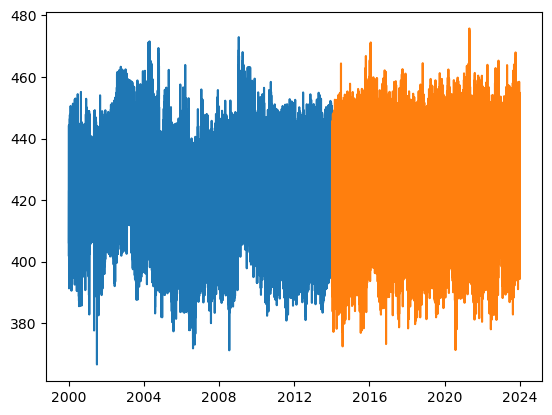

In [17]:
# For longwave radattion we used a quantile based rescalings

q05_target = np.quantile(df_atto[f"{var_atto}_filled"], q=0.01)
q95_target = np.quantile(df_atto[f"{var_atto}_filled"], q=0.99)

q05_source = np.quantile(df_zf2[f"{var_zf2}_filled"], q=0.01)
q95_source = np.quantile(df_zf2[f"{var_zf2}_filled"], q=0.99)

X_scaled = q05_target + (df_zf2[[f"{var_zf2}_filled"]] - q05_source) * (q95_target - q05_target) / (q95_source - q05_source)


plt.plot(X_scaled[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

24.0


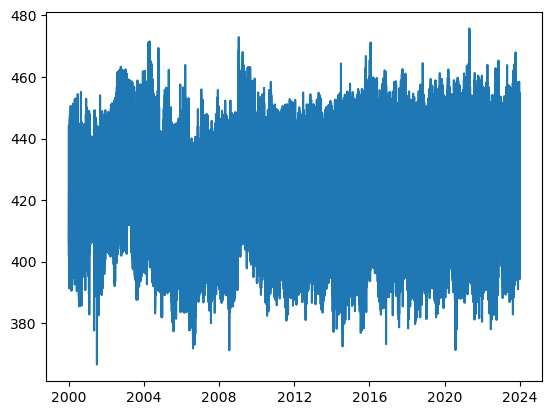

In [18]:
df_final_LW= pd.DataFrame(X_scaled[f"{var_zf2}_filled"])
df2 = df_atto.rename(columns={f"{var_atto}_filled": f"{var_zf2}_filled"})
df_final_LW = pd.concat([df_final_LW, df2[f"{var_zf2}_filled"]], axis=0)
print(df_final_LW.shape[0]/17520)
plt.plot(df_final_LW[f"{var_zf2}_filled"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


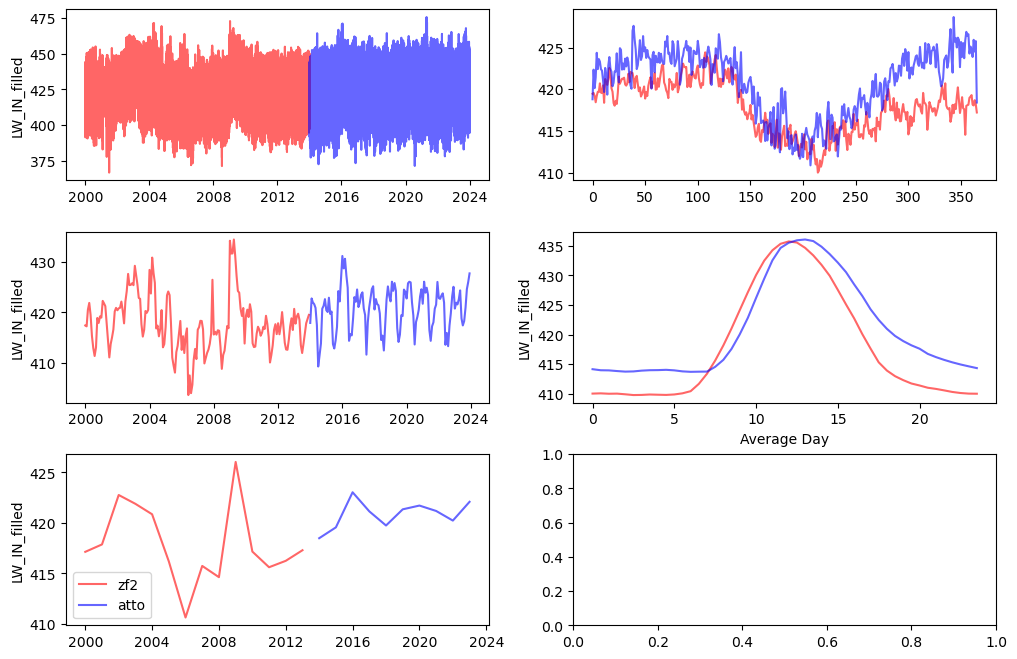

In [19]:
gen_plot(df_final_LW, f"{var_zf2}_filled")

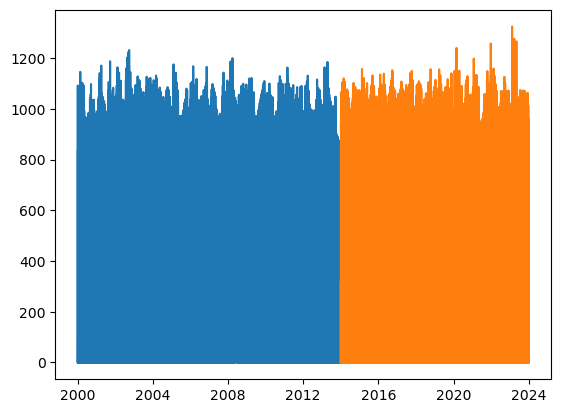

In [20]:
id = 3

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

24.0


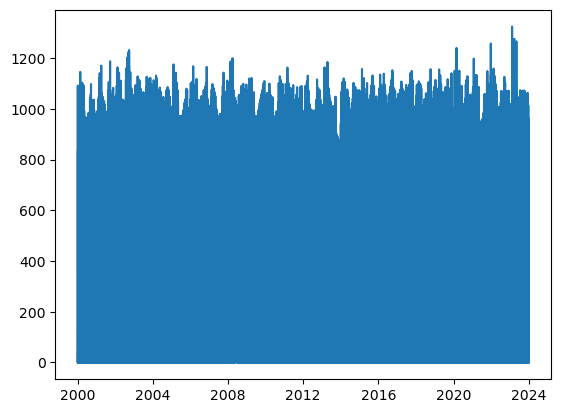

In [21]:
df_final_SW= pd.DataFrame(df_zf2[f"{var_zf2}_filled"])
df2 = df_atto.rename(columns={f"{var_atto}_filled": f"{var_zf2}_filled"})
df_final_SW = pd.concat([df_final_SW, df2[f"{var_zf2}_filled"]], axis=0)
print(df_final_SW.shape[0]/17520)
plt.plot(df_final_SW[f"{var_zf2}_filled"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


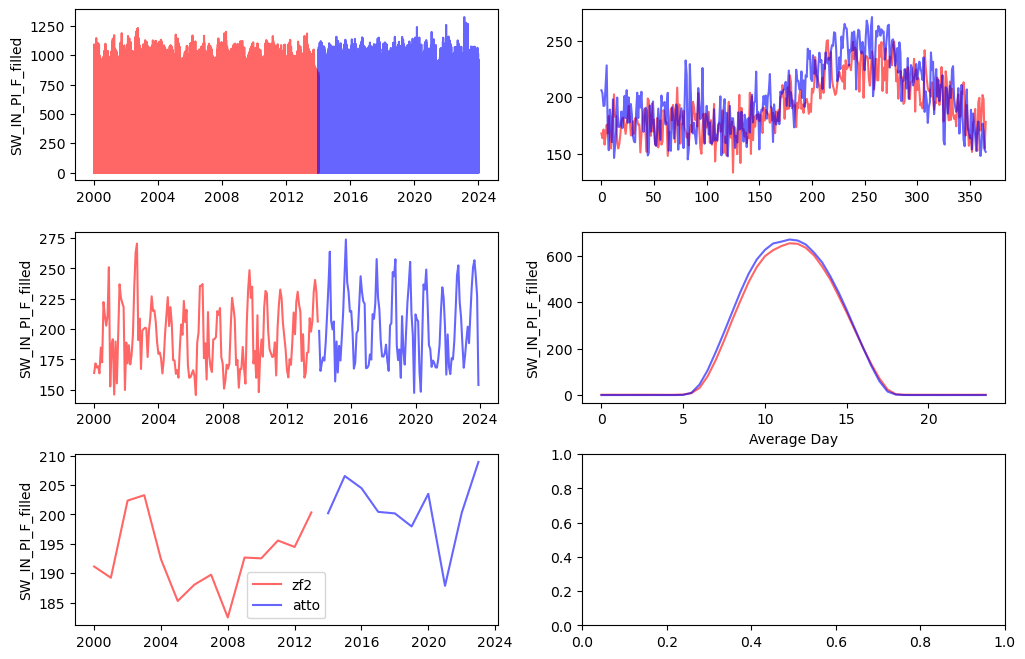

In [22]:
gen_plot(df_final_SW, f"{var_zf2}_filled")

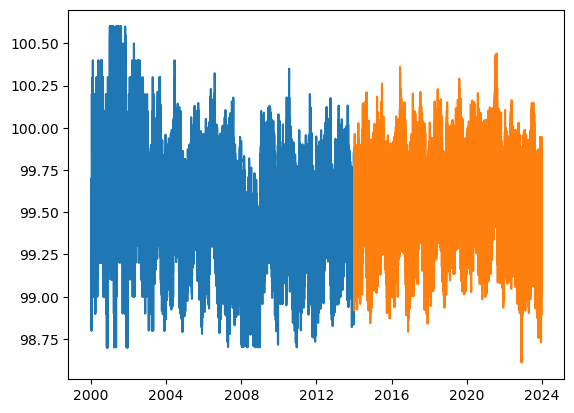

In [23]:
id = 4

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

24.0


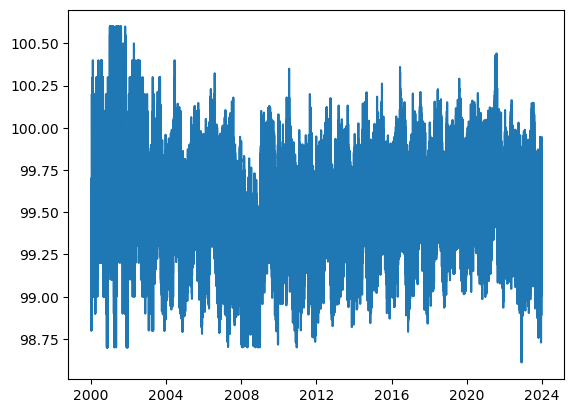

In [24]:
df_final_PRES= pd.DataFrame(df_zf2[f"{var_zf2}_filled"])
df2 = df_atto.rename(columns={f"{var_atto}_filled": f"{var_zf2}_filled"})
df_final_PRES = pd.concat([df_final_PRES, df2[f"{var_zf2}_filled"]], axis=0)
print(df_final_PRES.shape[0]/17520)
plt.plot(df_final_PRES[f"{var_zf2}_filled"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


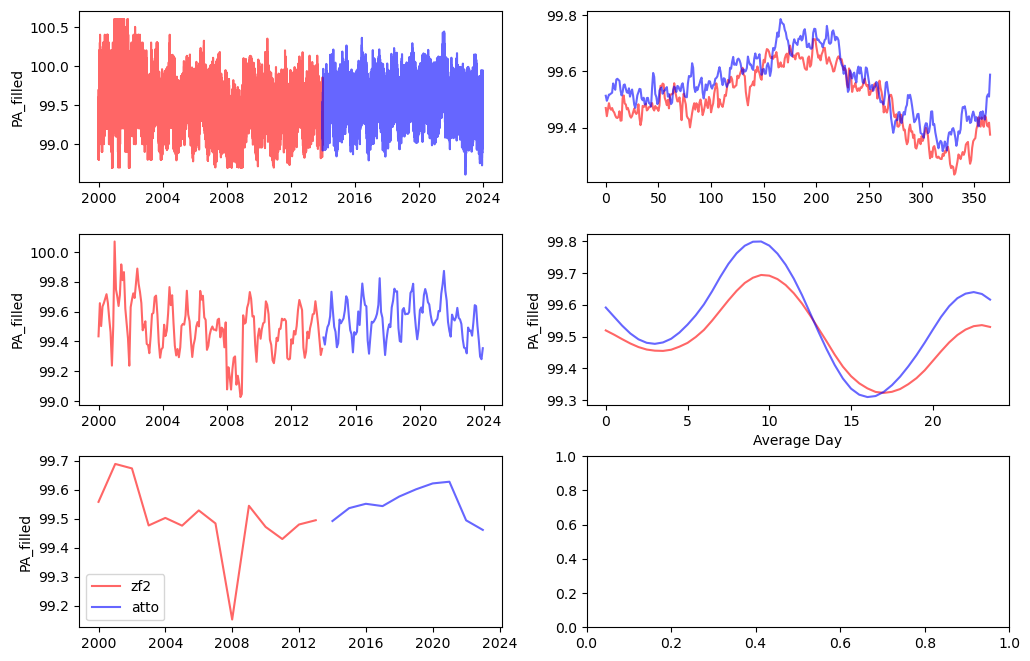

In [25]:
gen_plot(df_final_PRES, f"{var_zf2}_filled")

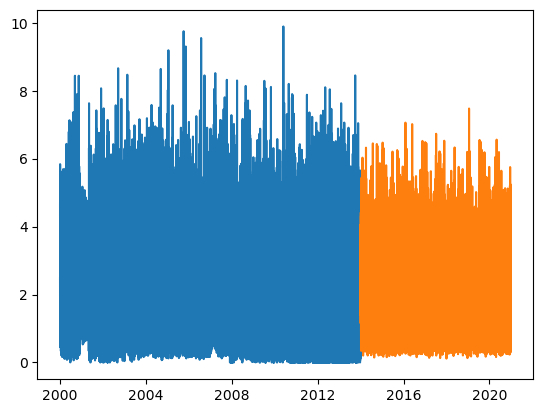

In [26]:
id = 5

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

In [27]:

ref = df_atto[[f"{var_atto}_filled"]].loc["2017-01-01":"2019-12-31"].copy()

last_two_years = df_atto[[f"{var_atto}_filled"]].last("3YE").copy()

# Shift the timestamps forward by 2 years
df_atto.loc[last_two_years.index,f"{var_atto}_filled"] = ref.values

df_atto[f"{var_atto}_filled"] = df_atto[f"{var_atto}_filled"].fillna(0.01)

#df_atto[[f"{var_atto}_filled"]].fillna(0.01, inplace=True)

/tmp/ipykernel_706432/3649323825.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_two_years = df_atto[[f"{var_atto}_filled"]].last("3YE").copy()


In [28]:
df_i = df_atto[[f"{var_atto}_filled"]]
nan_rows = df_i[df_i.isna().any(axis=1)]
print(nan_rows)

Empty DataFrame
Columns: [WSp_50m_filled]
Index: []


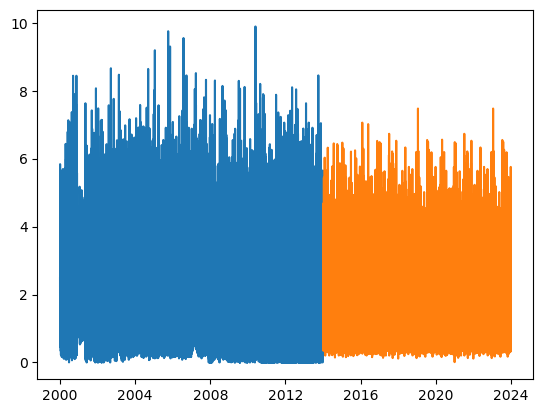

In [29]:
id = 5

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]


plt.plot(df_zf2[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

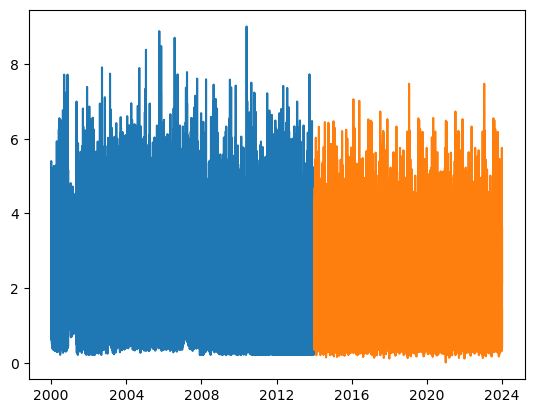

In [30]:
q05_target = np.quantile(df_atto[f"{var_atto}_filled"], q=0.01)
q95_target = np.quantile(df_atto[f"{var_atto}_filled"], q=0.99)

q05_source = np.quantile(df_zf2[f"{var_zf2}_filled"], q=0.02)
q95_source = np.quantile(df_zf2[f"{var_zf2}_filled"], q=0.98)

X_scaled = q05_target + (df_zf2[[f"{var_zf2}_filled"]] - q05_source) * (q95_target - q05_target) / (q95_source - q05_source)


plt.plot(X_scaled[f"{var_zf2}_filled"])
plt.plot(df_atto[f"{var_atto}_filled"])

24.0


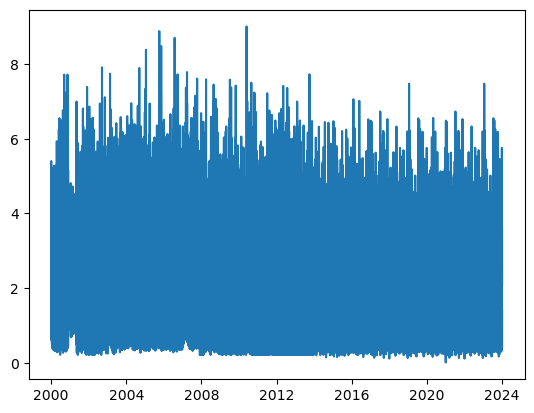

In [31]:
df_final_W= pd.DataFrame(X_scaled[f"{var_zf2}_filled"])
df2 = df_atto.rename(columns={f"{var_atto}_filled": f"{var_zf2}_filled"})
df_final_W = pd.concat([df_final_W, df2[f"{var_zf2}_filled"]], axis=0)
print(df_final_W.shape[0]/17520)
plt.plot(df_final_W[f"{var_zf2}_filled"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


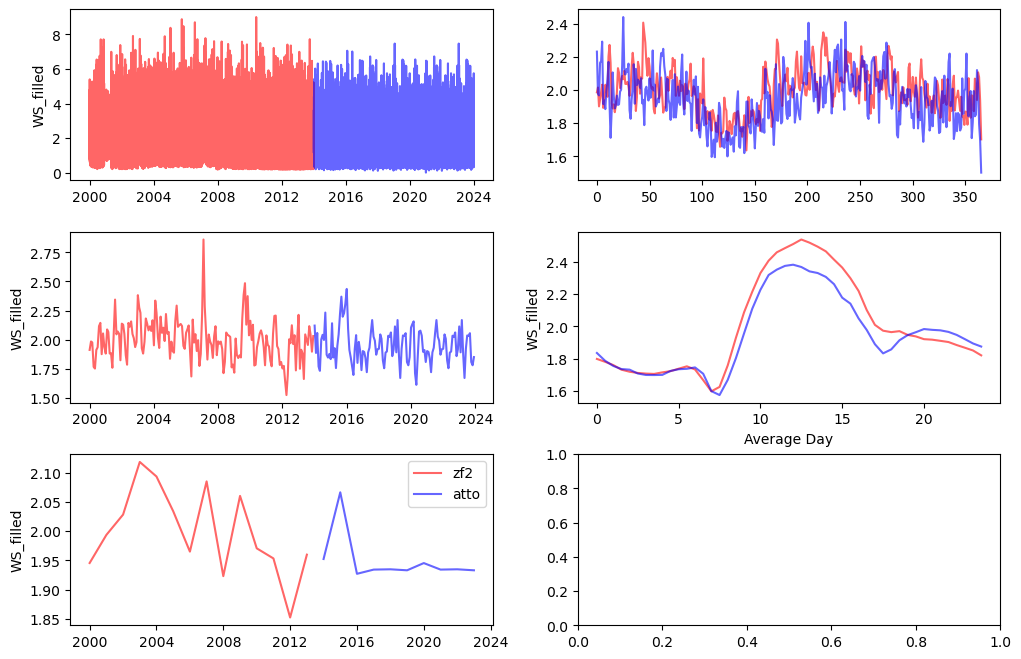

In [32]:
gen_plot(df_final_W, f"{var_zf2}_filled")

0.8579250371861792


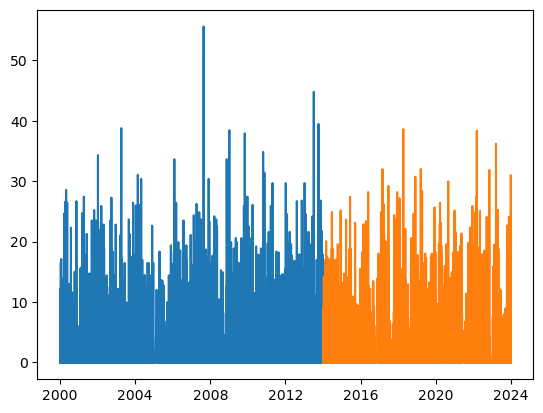

In [33]:
id = 6

var_atto = vars_atto[id]
var_zf2 = vars_zf2[id]

alpha = df_atto[var_atto].mean()/df_zf2[var_zf2].mean()
print(alpha)
plt.plot(df_zf2[f"{var_zf2}"]*alpha)
plt.plot(df_atto[f"{var_atto}"])

24.0


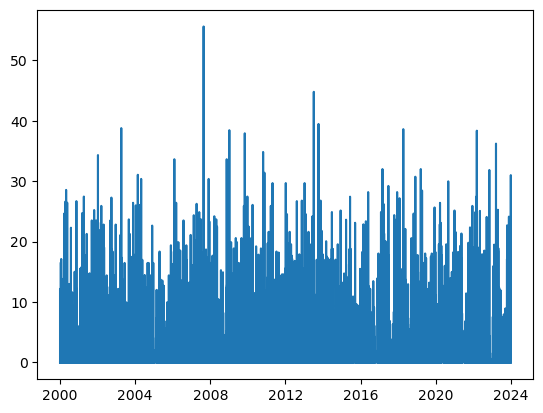

In [34]:
df_final_RAIN= pd.DataFrame(df_zf2[f"{var_zf2}"]* alpha)
df2 = df_atto.rename(columns={f"{var_atto}": f"{var_zf2}"})
df_final_RAIN = pd.concat([df_final_RAIN, df2[f"{var_zf2}"]], axis=0)
print(df_final_RAIN.shape[0]/17520)
plt.plot(df_final_RAIN[f"{var_zf2}"])

/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()
/tmp/ipykernel_706432/1941048921.py:52: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_zf2_grp = df.groupby(pd.Grouper(freq='30T'))[varnamef].mean()


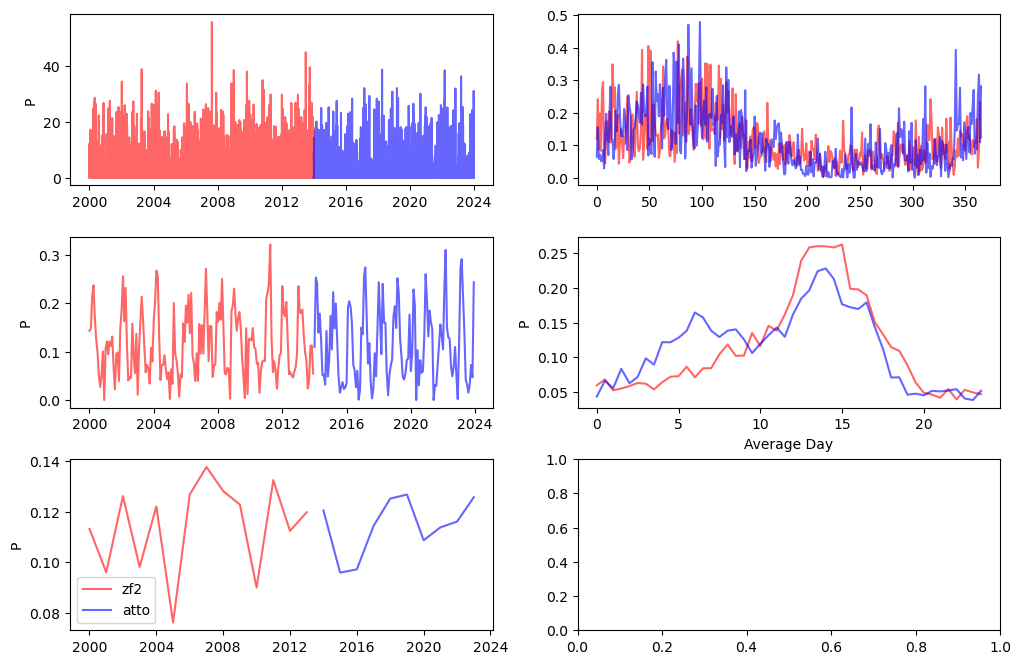

In [35]:
gen_plot(df_final_RAIN, f"{var_zf2}")

In [36]:
vars_zf2

['TA', 'Q', 'LW_IN', 'SW_IN_PI_F', 'PA', 'WS', 'P']

In [37]:
df_final_T[f"{vars_zf2[1]}_filled"] = df_final_Q[f"{vars_zf2[1]}_filled"]
df_final_T[f"{vars_zf2[2]}_filled"] = df_final_LW[f"{vars_zf2[2]}_filled"]
df_final_T[f"{vars_zf2[3]}_filled"] = df_final_SW[f"{vars_zf2[3]}_filled"]
df_final_T[f"{vars_zf2[4]}_filled"] = df_final_PRES[f"{vars_zf2[4]}_filled"]
df_final_T[f"{vars_zf2[5]}_filled"] = df_final_W[f"{vars_zf2[5]}_filled"]
df_final_T[f"{vars_zf2[6]}_filled"] = df_final_RAIN[f"{vars_zf2[6]}"]
df_final_T


,TA_filled,Year,Month,Day_of_year,Q_filled,LW_IN_filled,SW_IN_PI_F_filled,PA_filled,WS_filled,P_filled
2000-01-01 00:00:00,24.770,2000,1,1,0.021168,406.263226,0.0,99.300000,2.419767,0.0
2000-01-01 00:30:00,24.620,2000,1,1,0.021006,408.369166,0.0,99.200000,2.204513,0.0
2000-01-01 01:00:00,24.470,2000,1,1,0.020845,412.297490,0.0,99.200000,2.207182,0.0
2000-01-01 01:30:00,24.300,2000,1,1,0.020641,413.700135,0.0,99.200000,2.336156,0.0
2000-01-01 02:00:00,24.080,2000,1,1,0.020399,407.400736,0.0,99.100000,2.730195,0.0
...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:30:00,23.503,2023,12,365,0.018628,410.952674,0.0,99.354141,1.545667,0.0
2023-12-31 22:00:00,23.503,2023,12,365,0.018628,410.952674,0.0,99.354141,2.240000,0.0
2023-12-31 22:30:00,23.503,2023,12,365,0.018628,410.952674,0.0,99.354141,1.965333,0.0
2023-12-31 23:00:00,23.503,2023,12,365,0.018628,410.952674,0.0,99.354141,2.290667,0.0


In [38]:
f"✅"if (df_final_T.shape[0] % 17520 == 0) else f"❌"

'✅'

In [39]:
f"✅"if (~df_final_T.isna().any().any()) else f"❌"

'✅'

In [43]:

df_final_T.index.name = 'datetime'
df_final_T.to_csv(f"../data/ATTO_merged_gapfilled_2000_2023.csv")

In [41]:
df_final_T.index[0]

Timestamp('2000-01-01 00:00:00')

In [42]:
df_final_T.index[-1]

Timestamp('2023-12-31 23:30:00')